# PPG Leader Model

In [1]:
# For data handling
import pandas as pd
import numpy as np

# To manage model loading and save paths
import os
import json
import joblib
from datetime import datetime

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Machine Learning
from sklearn import tree, svm
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from pytorch_tabnet.tab_model import TabNetClassifier

In [2]:
# Creating a timestamp for saving model version number by date
timestamp = datetime.now().strftime("%Y_%m_%d")

# Establishing file paths for loading and saving data
CLEANED_PATH = "../../data/cleaned"
PROCESSED_PATH = "../../data/processed"
ML_PATH = "../../data/models/ml"
DL_PATH = "../../data/models/dl"
os.makedirs(ML_PATH, exist_ok=True)
os.makedirs(DL_PATH, exist_ok=True)

# Create a timestamped subdirectory inside DL and ML Path
versioned_dl_path = os.path.join(DL_PATH, f"ppg_leader_{timestamp}")
os.makedirs(versioned_dl_path, exist_ok=True)

versioned_ml_path = os.path.join(ML_PATH, f"ppg_leader_{timestamp}")
os.makedirs(versioned_ml_path, exist_ok=True)

In [3]:
# Loading the data sets needed 
ppg_df = pd.read_csv(f"{PROCESSED_PATH}/ppg_eda_cleaned.csv")
all_seasons_df = pd.read_csv(f"{CLEANED_PATH}/player_all_years.csv")

In [4]:
ppg_df.drop(columns=["Unnamed: 0"], inplace=True)

In [5]:
ppg_df.dropna(inplace=True)

In [6]:
# Creating a DataFrame to hold the Season column so it can be added back to the ppg_df
selected_features = list(ppg_df.drop(columns=["is_PPG_Leader"]).columns)
reduced_with_season = all_seasons_df[selected_features + ["Season", "is_PPG_Leader"]].dropna()

In [7]:
# Checking to see if indexes match before merging
ppg_df.index.equals(reduced_with_season.index)

True

In [8]:
# Merging the DataFrames
ppg_df["Season"] = reduced_with_season["Season"]

In [9]:
ppg_df.drop(columns=["PPG"], inplace=True)

In [10]:
# Previewing the data
ppg_df.head(5)

,VORP,FT,WS,TOV,FG,USG%,2P,3P,is_PPG_Leader,Season
0,7.5,9.2,16.1,3.3,9.7,32.0,8.1,1.6,1,2010
1,10.3,7.8,18.5,3.4,10.1,33.5,8.4,1.7,0,2010
2,2.9,7.4,7.9,3.0,10.0,33.4,9.1,0.9,0,2010
3,4.4,6.0,9.4,3.2,9.8,32.3,8.5,1.4,0,2010
4,7.9,6.9,13.0,3.3,9.3,34.9,8.4,0.9,0,2010


In [11]:
# Checking to make sure no null values remain
print(ppg_df.isnull().sum())

VORP             0
FT               0
WS               0
TOV              0
FG               0
USG%             0
2P               0
3P               0
is_PPG_Leader    0
Season           0
dtype: int64


In [12]:
X = ppg_df.drop(columns=["is_PPG_Leader", "Season"])
y = ppg_df["is_PPG_Leader"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler_lr = StandardScaler()
X_train_scaled_lr = scaler_lr.fit_transform(X_train)
X_test_scaled_lr = scaler_lr.transform(X_test)

In [14]:
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled_lr, y_train)
y_pred_lr = model_lr.predict(X_test_scaled_lr)

In [15]:
# Model results
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[1940    0]
 [   2    1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1940
           1       1.00      0.33      0.50         3

    accuracy                           1.00      1943
   macro avg       1.00      0.67      0.75      1943
weighted avg       1.00      1.00      1.00      1943



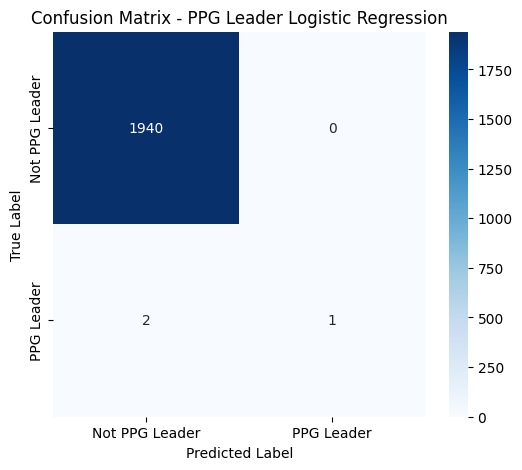

In [16]:
# Computing confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plot of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not PPG Leader", "PPG Leader"],
            yticklabels=["Not PPG Leader", "PPG Leader"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - PPG Leader Logistic Regression")
plt.show()

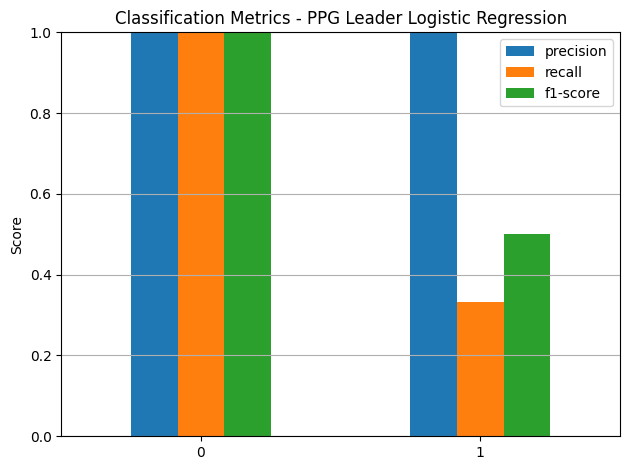

In [17]:
report = classification_report(y_test, y_pred_lr, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Bar chart for precision, recall and f1-score
df_report.iloc[:2][["precision", "recall", "f1-score"]].plot(kind="bar")
plt.title("Classification Metrics - PPG Leader Logistic Regression")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [18]:
scaler_clf = MinMaxScaler()
X_train_scaled_clf = scaler_clf.fit_transform(X_train)
X_test_scaled_clf = scaler_clf.transform(X_test)

In [19]:
model_clf = tree.DecisionTreeClassifier(class_weight="balanced")
model_clf.fit(X_train_scaled_clf, y_train)
y_pred_clf = model_lr.predict(X_test_scaled_clf)


[Text(0.13793103448275862, 0.9642857142857143, 'x[4] <= 0.778\ngini = 0.5\nsamples = 7771\nvalue = [3885.5, 3885.5]'),
 Text(0.06896551724137931, 0.8928571428571429, 'gini = -0.0\nsamples = 7650\nvalue = [3830.916, 0.0]'),
 Text(0.10344827586206896, 0.9285714285714286, 'True  '),
 Text(0.20689655172413793, 0.8928571428571429, 'x[2] <= 0.516\ngini = 0.027\nsamples = 121\nvalue = [54.584, 3885.5]'),
 Text(0.1724137931034483, 0.9285714285714286, '  False'),
 Text(0.13793103448275862, 0.8214285714285714, 'gini = 0.0\nsamples = 59\nvalue = [29.546, 0.0]'),
 Text(0.27586206896551724, 0.8214285714285714, 'x[5] <= 0.431\ngini = 0.013\nsamples = 62\nvalue = [25.039, 3885.5]'),
 Text(0.20689655172413793, 0.75, 'gini = 0.0\nsamples = 24\nvalue = [12.019, 0.0]'),
 Text(0.3448275862068966, 0.75, 'x[7] <= 0.179\ngini = 0.007\nsamples = 38\nvalue = [13.02, 3885.5]'),
 Text(0.27586206896551724, 0.6785714285714286, 'gini = 0.0\nsamples = 5\nvalue = [2.504, 0.0]'),
 Text(0.41379310344827586, 0.678571428

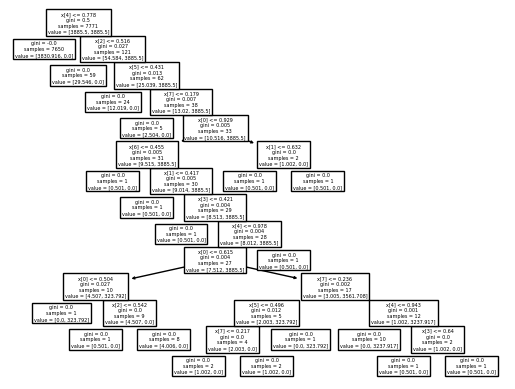

In [20]:
tree.plot_tree(model_clf)

In [21]:
# Model results
print(confusion_matrix(y_test, y_pred_clf))
print(classification_report(y_test, y_pred_clf))

[[1940    0]
 [   3    0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1940
           1       0.00      0.00      0.00         3

    accuracy                           1.00      1943
   macro avg       0.50      0.50      0.50      1943
weighted avg       1.00      1.00      1.00      1943



c:\Users\Kay\Desktop\General-Projects\nba_awards_predictions\nba_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kay\Desktop\General-Projects\nba_awards_predictions\nba_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Kay\Desktop\General-Projects\nba_awards_predictions\nba_env\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter

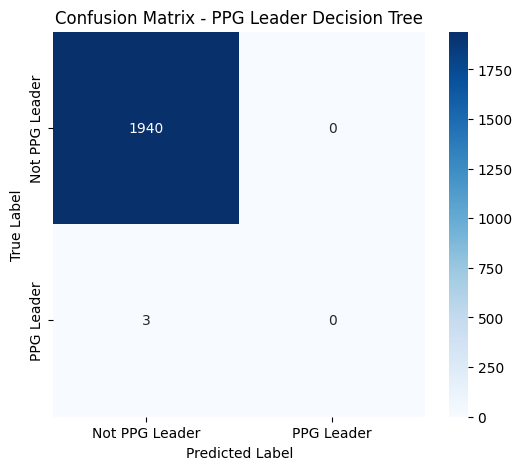

In [22]:
# Computing confusion matrix
cm = confusion_matrix(y_test, y_pred_clf)

# Plot of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not PPG Leader", "PPG Leader"],
            yticklabels=["Not PPG Leader", "PPG Leader"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - PPG Leader Decision Tree")
plt.show()

In [23]:
# Setting train, test, splits for deep learning approach
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train_nn)
X_test_nn = scaler_nn.transform(X_test_nn)

In [25]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_nn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_nn.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_nn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_nn.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [26]:
class PPGNET(nn.Module):
    """
    A feedforward neural network for predicting NBA PPG Leader likelihood based on player stats.

    Args:
        input_dim (int): Number of input features
    """
    def __init__(self, input_dim):
        """
        Initializes the DPOYNet model with a series of fully connected layers,
        LeakyReLu activations, and dropout regularization.

        Args:
            input_dim (int): Number of input features
        """
        super(PPGNET, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), # The expanding architecture
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),
            
            nn.Linear(32, 16),
            nn.LeakyReLU(0.1),
            
            nn.Linear(16, 1),
            
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Defines the forward pass of the network

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim)
            
        Returns:
            torch.Tensor: Output tensor with shape (batch_size, 1), representing MVP prediction scores.
        """
        
        return self.network(x)
        

In [27]:
# Calculate class counts (assuming y_train is a pandas Series or NumPy array)
neg = (y_train_nn == 0).sum()
pos = (y_train_nn == 1).sum()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Compute pos_weight = (# of negative samples / # of positive samples)
pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

In [28]:
# Model training
model_nn = PPGNET(input_dim=X_train_nn.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001)

num_epochs = 200
model_nn.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model_nn(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}")

Epoch 1/200, Loss: 325.9392
Epoch 2/200, Loss: 52.7203
Epoch 3/200, Loss: 151.5966
Epoch 4/200, Loss: 35.3422
Epoch 5/200, Loss: 38.9612
Epoch 6/200, Loss: 34.9793
Epoch 7/200, Loss: 40.0461
Epoch 8/200, Loss: 29.2691
Epoch 9/200, Loss: 18.5386
Epoch 10/200, Loss: 59.1066
Epoch 11/200, Loss: 28.6392
Epoch 12/200, Loss: 47.4046
Epoch 13/200, Loss: 31.2446
Epoch 14/200, Loss: 30.2973
Epoch 15/200, Loss: 31.2538
Epoch 16/200, Loss: 24.3924
Epoch 17/200, Loss: 29.5036
Epoch 18/200, Loss: 19.0397
Epoch 19/200, Loss: 18.3034
Epoch 20/200, Loss: 25.9991
Epoch 21/200, Loss: 20.3450
Epoch 22/200, Loss: 36.2745
Epoch 23/200, Loss: 21.6282
Epoch 24/200, Loss: 17.3845
Epoch 25/200, Loss: 32.7342
Epoch 26/200, Loss: 14.3609
Epoch 27/200, Loss: 22.0902
Epoch 28/200, Loss: 17.2141
Epoch 29/200, Loss: 22.1347
Epoch 30/200, Loss: 17.8172
Epoch 31/200, Loss: 29.7620
Epoch 32/200, Loss: 21.6948
Epoch 33/200, Loss: 17.3630
Epoch 34/200, Loss: 24.7162
Epoch 35/200, Loss: 12.3036
Epoch 36/200, Loss: 19.2843

In [29]:
model_nn.eval()
prob_threshold = 1 / (1 + np.exp(-7.0))

with torch.no_grad():
    y_pred_probs_nn = model_nn(X_test_tensor.to(device)).cpu().numpy()
    y_pred_nn = (y_pred_probs_nn > prob_threshold).astype(int)

print(confusion_matrix(y_test_nn, y_pred_nn))
print(classification_report(y_test_nn, y_pred_nn))

[[1854   86]
 [   0    3]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1940
           1       0.03      1.00      0.07         3

    accuracy                           0.96      1943
   macro avg       0.52      0.98      0.52      1943
weighted avg       1.00      0.96      0.98      1943



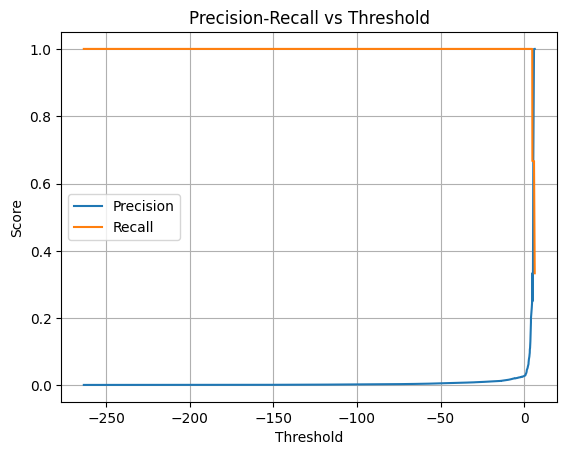

In [30]:
precision_nn, recall_nn, thresholds_nn = precision_recall_curve(y_test, y_pred_probs_nn)

plt.plot(thresholds_nn, precision_nn[:-1], label='Precision')
plt.plot(thresholds_nn, recall_nn[:-1], label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
def predict_ppg_leader(
    model: torch.nn.Module,
    data: pd.DataFrame,
    feature_columns: list[str],
    player_id_column: str,
    threshold: float,
    scaler: object,
    device: torch.device = torch.device("cpu"),
    return_probs: bool = True
) -> pd.DataFrame:
    """
    
    Use a trained PyTorch model to predict PPG Leaders from unlabeled data

    Args:
        model (torch.nn.Module): Trained PyTorch model (no final sigmoid)
        data (pd.DataFrame): Input DataFrame with player-season stats
        feature_columns (list[str]): List of columns used as features
        player_id_column (str): Column name for identifying players
        threshold (float): Logit threshold to label a player as PPG Leader
        scaler (object): Scaler used during model training
        device (torch.device): CPU or GPU. Defaults to CPU
        return_probs (bool): If True, include predicted logit and probability columns

    Returns:
        pd.DataFrame: Subset of input data predicted as PPG Leaders, with optional confidence scores

    """
    model.eval()
    
    # Preprocess input features
    X = scaler.transform(data[feature_columns])
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    
    # Get logits from model
    with torch.no_grad():
        logits = model(X_tensor).cpu().numpy().flatten()
    
    # Apply threshold to get binary predictions
    predictions = (logits > threshold).astype(int)
    
    # Append predictions and optional scores
    data = data.copy()
    data["predicted_ppg_leader"] = predictions

    if return_probs:
        data["logit"] = logits
        data["probability"] = 1 / (1 + np.exp(-logits))  # manually apply sigmoid
    
    # Filter to PPG Leader candidates
    ppg_leader = data[data["predicted_ppg_leader"] == 1].sort_values(by="logit", ascending=False)

    return ppg_leader

In [32]:
# Loading a cleaned dataset that is not scaled
all_season_df = pd.read_csv(f"{CLEANED_PATH}/player_all_years.csv")

all_season_df.drop(columns=["is_MVP", "is_DPOY", "PPG"], inplace=True)

# Setting a target season
#target_season = 2018

# Filtering the DataFrame
#current_season_df = all_season_df[all_season_df["Season"] == target_season].copy()

#current_season_df.reset_index(drop=True, inplace=True)

In [33]:
feature_list = [
    "VORP", "FT", "WS",
    "TOV", "FG", "USG%", "2P",
    "3P"
]

Now that we're confident in the models ability to predict PPG leaders, we're going to test it on a fully cleaned dataset. For reference, here is a list of the actual ppg leaders by season:
* 2024-25	NBA	Shai Gilgeous-Alexander	    32.68	OKC
* 2023-24	NBA	Luka Dončić	                33.86	DAL
* 2022-23	NBA	Joel Embiid	                33.08	PHI
* 2021-22	NBA	Joel Embiid	                30.57	PHI
* 2020-21	NBA	Stephen Curry	            31.98	GSW
* 2019-20	NBA	James Harden	            34.34	HOU
* 2018-19	NBA	James Harden	            36.13	HOU
* 2017-18	NBA	James Harden	            30.43	HOU
* 2016-17	NBA	Russell Westbrook	        31.58	OKC
* 2015-16	NBA	Stephen Curry	            30.06	GSW
* 2014-15	NBA	Russell Westbrook	        28.15	OKC
* 2013-14	NBA	Kevin Durant	            32.01	OKC

In [34]:
ppg_leader = predict_ppg_leader(
    model=model_nn,
    data=all_season_df,
    feature_columns=feature_list,
    player_id_column="Player",  
    threshold=7.0,
    scaler=scaler_nn,
    device=device
)

print(ppg_leader[["Player", "Team", "logit", "probability", "Season"]].head(10))


                 Player Team     logit  probability  Season
5426       James Harden  HOU  9.185438     0.999897    2019
4167  Russell Westbrook  OKC  8.364756     0.999767    2017
6134       James Harden  HOU  7.717895     0.999555    2020
2327       Kevin Durant  OKC  7.545346     0.999472    2014
4762       James Harden  HOU  7.402650     0.999391    2018
4168       James Harden  HOU  7.324544     0.999341    2017
8982      Luka DonÄiÄ  DAL  7.168295     0.999230    2024
3589      Stephen Curry  GSW  7.048997     0.999132    2016


C:\Users\Kay\AppData\Local\Temp\ipykernel_26176\255486880.py:48: RuntimeWarning: overflow encountered in exp
  data["probability"] = 1 / (1 + np.exp(-logits))  # manually apply sigmoid


The results here are 99% accurate. At first glance it may be confusing to read. The NBA tracks season across two calendar years (e.g. 2024 - 2025) but our data is presented as one calendar year, and will need to be cleared up in the future to make the model easier for everyone to understand.

In [35]:
# Deep Learning Model Save
model_path = os.path.join(versioned_dl_path, "ppg_model_weights.pth")
torch.save(model_nn.state_dict(), model_path)

# Deep Learning Scaler save
scaler_path = os.path.join(versioned_dl_path, "ppg_scaler.pkl")
joblib.dump(scaler_nn, scaler_path)

# Features and metadata save
feature_list_path = os.path.join(versioned_dl_path, "ppg_feature_list.json")
metadata = {
    "timestamp": timestamp,
    "input_dim" : len(feature_list),
    "features" : feature_list,
    "threshold" : 7.0,
    "notes" : "Deep learning PPG Leader model trained on all-season data"
}

# Feature list save

with open(feature_list_path, "w") as f:
    json.dump(metadata, f, indent=4)


In [36]:
# Machine Learning Model save
ml_model_path = os.path.join(versioned_ml_path, "ppg_ml_model.pkl")
joblib.dump(model_lr, ml_model_path)

# Machine Learning Scaler save
ml_scaler_path = os.path.join(versioned_ml_path, "ppg__ml_scaler.pkl")
joblib.dump(scaler_lr, ml_scaler_path)

# Metadata save

ml_metadata = {
    "timestamp": timestamp,
    "model_type" : str(type(model_lr)).split("'")[1],
    "input_dim" : len(feature_list),
    "features" : feature_list,
    "threshold" : 0.5,
    "notes" : "Best ML Model for PPG Leader prediction"
}

ml_metadata_path = os.path.join(versioned_ml_path, "ppg_ml_feature_list.json")
with open(ml_metadata_path, "w") as f:
    json.dump(ml_metadata, f, indent=4)
